In [ ]:
# 1. 문제 정의
# 4909명의 건강 정보를 가지고 뇌졸중 유무를 판단하는 모델을 설계해보자!

In [1]:
# 라이브러리 불러오기가 우선!!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 2. 데이터 수집
# data 폴더에 csv 파일 추가하고, 해당 파일 불러오기!
data = pd.read_csv('./data/healthcare-dataset-stroke-data.csv')
data.set_index('id', inplace = True)
data
# 데이터 불러온 후에 'id' 컬럼을 index로 설정하기

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
77,Female,13.0,0,0,No,children,Rural,85.81,18.6,Unknown,0
84,Male,55.0,0,0,Yes,Private,Urban,89.17,31.5,never smoked,0
91,Female,42.0,0,0,No,Private,Urban,98.53,18.5,never smoked,0
99,Female,31.0,0,0,No,Private,Urban,108.89,52.3,Unknown,0
129,Female,24.0,0,0,No,Private,Urban,97.55,26.2,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...
72911,Female,57.0,1,0,Yes,Private,Rural,129.54,60.9,smokes,0
72914,Female,19.0,0,0,No,Private,Urban,90.57,24.2,Unknown,0
72915,Female,45.0,0,0,Yes,Private,Urban,172.33,45.3,formerly smoked,0


In [5]:
# 데이터 정보 확인
data.info()

# 결측치 없음
# 10개의 입력 특성(X)과 1개의 정답데이터(y - stroke)를 가지고 있다.

<class 'pandas.DataFrame'>
Index: 4909 entries, 77 to 72940
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4909 non-null   str    
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   int64  
 3   heart_disease      4909 non-null   int64  
 4   ever_married       4909 non-null   str    
 5   work_type          4909 non-null   str    
 6   Residence_type     4909 non-null   str    
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   str    
 10  stroke             4909 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 609.6 KB


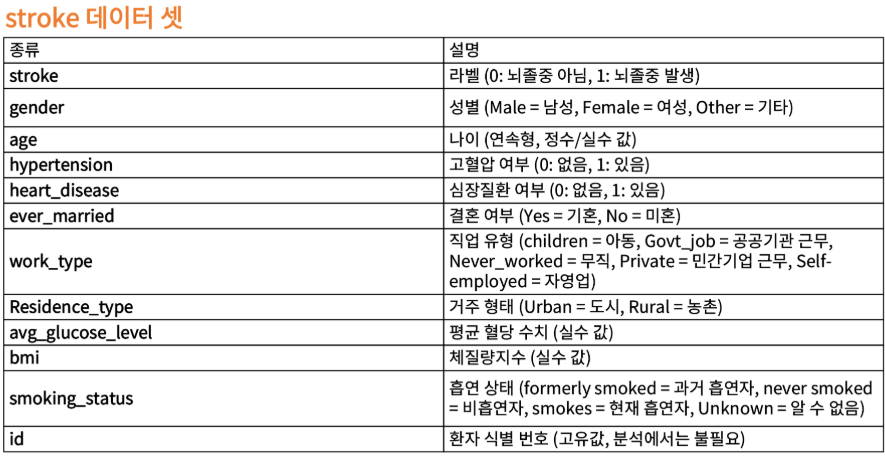

In [6]:
# 문제 데이터 / 정답 데이터 분리
X = data.drop('stroke', axis = 1)# stroke 컬럼 제외 나머지 다 선택.  #drop으로 빼버려도 됨
y = data['stroke']# stroke 컬럼

X.shape, y.shape # (4909, 10), (4909, )

((4909, 10), (4909,))

In [7]:
# 데이터 분리 - 훈련용 / 테스트용 7:3
# 슬라이싱 -> 안씀
# 대신 데이터 분리 도구 사용 -> train_test_split

# 데이터 분리 도구 불러오기(랜덤 샘플링 도구)
from sklearn.model_selection import train_test_split

In [9]:
# 분리한 후 나오는 결과값의 순서에 맞게 변수 순서를 올바르게 지정해야 한다!!
X_train, X_test, y_train, y_test = train_test_split(X, y, # 분리 대상(문제, 정답) 
                                                    test_size = 0.3, # 분리 비율 -> 7:3
                                                    random_state = 2026) # 랜덤 고정(숫자의 의미는 없음)
                                                                        # .seed() 랑 같은 역할

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3436, 10), (1473, 10), (3436,), (1473,))

In [10]:
# 의사결정나무 불러오기
from sklearn.tree import DecisionTreeClassifier

In [11]:
# 모델 학습

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Female'